# Inspect SSL Dataset

这个 notebook 用来检查 `dataloader.ssl_dataset.SingleStepDataset` 读取出来的数据是否正常。

主要检查内容：

- 数据集样本数量和文件路径
- `audio_wave / spectrogram / depth / rgb / doa_map / distant_map` 的 shape
- DOA 和 distance 标签是否是概率分布
- 音频波形、频谱/IPD、图像、DOA 分布和距离分布可视化
- 整个 dataset 的 DOA / distance 标签分布

In [19]:
from pathlib import Path
import sys

import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

REPO_ROOT = Path("/home/kemove/yyz/audio-nav/ws_col")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from dataloader.ssl_dataset import SingleStepDataset

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. 配置数据集

如果你的数据不在默认路径，修改 `DATA_ROOT` 即可。

In [34]:
DATA_ROOT = REPO_ROOT / "synced_dataset/train"
ODOM_NAME = "lio_odom"
AUDIO_FEAT = "ipd"        # ipd / spec / phase / both / gcc_phat_complex
AUDIO_CHANNELS = (1, 2, 3, 4)
IPD_PAIRS = ((0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3))
IMAGE_SIZE = (224, 224)
USE_COMPRESS = False
REQUIRE_DEPTH = False    # 新 dataloader 模式：False 时缺 depth 的样本也会读入，depth 用全 0 占位

print(DATA_ROOT)
print("exists:", DATA_ROOT.exists())
print("require_depth:", REQUIRE_DEPTH)

/home/kemove/yyz/audio-nav/ws_col/synced_dataset/train
exists: True
require_depth: False


In [35]:
dataset = SingleStepDataset(
    root_dir=str(DATA_ROOT),
    odom_name=ODOM_NAME,
    audio_feat=AUDIO_FEAT,
    audio_channels=AUDIO_CHANNELS,
    ipd_pairs=IPD_PAIRS,
    image_size=IMAGE_SIZE,
    use_compress=USE_COMPRESS,
    require_depth=REQUIRE_DEPTH,
)

print("num samples:", len(dataset))
missing_depth = sum(item["depth"] is None for item in dataset.file_list)
print("samples without depth:", missing_depth)
print("samples with depth:", len(dataset) - missing_depth)
print("first item:")
for key, value in dataset.file_list[0].items():
    print(f"  {key}: {value}")

num samples: 3889
samples without depth: 551
samples with depth: 3338
first item:
  dataset_dir: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3
  sample_id: 000000
  audio: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/audio/000000.wav
  depth: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/depth/000000.png
  rgb: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/color/000000.png
  doa: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/doa_lio_odom/000000.npy
  distance: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/distance_lio_odom/000000.npy
  odom: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/lio_odom/000000.npy


## 2. 检查每个 clock 的匹配情况

`SingleStepDataset` 现在是按 sample 过滤，不会因为一个 clock 里有一部分 sample 缺失就跳过整个目录。`REQUIRE_DEPTH=True` 时，一个样本需要同时存在 `audio / depth / doa_<odom_name> / distance_<odom_name>`；`REQUIRE_DEPTH=False` 时，缺 depth 的样本也可以进入，depth 会用全 0 占位。

In [36]:
def count_files(directory, suffixes):
    if not directory.exists():
        return 0
    return sum(len(list(directory.glob(f"*{suffix}"))) for suffix in suffixes)

def has_modality_file(directory, sample_id, suffixes):
    return any((directory / f"{sample_id}{suffix}").exists() for suffix in suffixes)

dataset_dirs = [DATA_ROOT] if (DATA_ROOT / "audio").exists() else sorted(path for path in DATA_ROOT.iterdir() if path.is_dir())

for dataset_dir in dataset_dirs:
    audio_dir = dataset_dir / "audio"
    depth_dir = dataset_dir / "depth"
    color_dir = dataset_dir / "color"
    doa_dir = dataset_dir / f"doa_{ODOM_NAME}"
    distance_dir = dataset_dir / f"distance_{ODOM_NAME}"

    matched = 0
    missing_examples = []
    for audio_path in sorted(audio_dir.glob("*.wav")):
        sample_id = audio_path.stem
        depth_ok = has_modality_file(depth_dir, sample_id, [".png", ".npy", ".jpg", ".jpeg"])
        doa_ok = (doa_dir / f"{sample_id}.npy").exists()
        distance_ok = (distance_dir / f"{sample_id}.npy").exists()
        sample_ok = doa_ok and distance_ok and (depth_ok or not REQUIRE_DEPTH)
        if sample_ok:
            matched += 1
        elif len(missing_examples) < 5:
            missing_examples.append((sample_id, depth_ok, doa_ok, distance_ok))

    print(f"\n{dataset_dir.name}")
    print("  audio wav:       ", count_files(audio_dir, [".wav"]))
    print("  depth files:     ", count_files(depth_dir, [".png", ".npy", ".jpg", ".jpeg"]))
    print("  color files:     ", count_files(color_dir, [".png", ".npy", ".jpg", ".jpeg"]))
    print("  doa files:       ", count_files(doa_dir, [".npy"]))
    print("  distance files:  ", count_files(distance_dir, [".npy"]))
    print("  matched samples with current REQUIRE_DEPTH:", matched)
    if missing_examples:
        print("  first missing examples: sample_id, depth_ok, doa_ok, distance_ok")
        for example in missing_examples:
            print("   ", example)


clock3
  audio wav:        273
  depth files:      273
  color files:      273
  doa files:        273
  distance files:   273
  matched samples with current REQUIRE_DEPTH: 273

clock4
  audio wav:        298
  depth files:      0
  color files:      298
  doa files:        290
  distance files:   290
  matched samples with current REQUIRE_DEPTH: 290
  first missing examples: sample_id, depth_ok, doa_ok, distance_ok
    ('000000', False, False, False)
    ('000001', False, False, False)
    ('000002', False, False, False)
    ('000003', False, False, False)
    ('000004', False, False, False)

clock5
  audio wav:        255
  depth files:      0
  color files:      255
  doa files:        247
  distance files:   247
  matched samples with current REQUIRE_DEPTH: 247
  first missing examples: sample_id, depth_ok, doa_ok, distance_ok
    ('000000', False, False, False)
    ('000001', False, False, False)
    ('000002', False, False, False)
    ('000003', False, False, False)
    ('000004

## 3. 检查单个样本

In [37]:
SAMPLE_INDEX = 100
sample = dataset[SAMPLE_INDEX]

print("sample index:", SAMPLE_INDEX)
print("path:", sample["path"])
print("sample_id:", sample["sample_id"])
print("dataset_dir:", sample["dataset_dir"])
print("sample_rate:", sample["sample_rate"])
print("has_depth_file:", dataset.file_list[SAMPLE_INDEX]["depth"] is not None)
print()

for key in ["audio_wave", "spectrogram", "depth", "rgb", "doa_map", "distant_map", "distance", "doa_deg", "pose", "sound_source"]:
    value = sample[key]
    if torch.is_tensor(value):
        print(f"{key:12s}: shape={tuple(value.shape)}, dtype={value.dtype}, min={float(value.min()):.4f}, max={float(value.max()):.4f}")
    else:
        print(f"{key:12s}: {value}")

print()
print("doa_map sum:", float(sample["doa_map"].sum()))
print("distant_map sum:", float(sample["distant_map"].sum()))
print("doa peak bin:", int(sample["doa_map"].argmax()))
print("distance peak bin:", int(sample["distant_map"].argmax()))
print("distance xy/3d:", sample["distance"].tolist())
print("doa signed deg:", float(sample["doa_deg"]))

sample index: 100
path: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3/audio/000100.wav
sample_id: 000100
dataset_dir: /home/kemove/yyz/audio-nav/ws_col/synced_dataset/train/clock3
sample_rate: 16000
has_depth_file: True

audio_wave  : shape=(4, 16000), dtype=torch.float32, min=-0.3322, max=0.1394
spectrogram : shape=(12, 257, 101), dtype=torch.float32, min=-1.0000, max=1.0000
depth       : shape=(1, 224, 224), dtype=torch.float32, min=0.0000, max=21.5593
rgb         : shape=(3, 224, 224), dtype=torch.float32, min=0.0667, max=0.9451
doa_map     : shape=(360,), dtype=torch.float32, min=0.0000, max=0.0980
distant_map : shape=(120,), dtype=torch.float32, min=0.0000, max=0.1497
distance    : shape=(2,), dtype=torch.float32, min=1.0728, max=1.0729
doa_deg     : shape=(), dtype=torch.float32, min=-122.9921, max=-122.9921
pose        : shape=(3,), dtype=torch.float32, min=-1.5049, max=0.0408
sound_source: shape=(3,), dtype=torch.float32, min=-0.9260, max=0.9441

doa_map sum: 1.

## 3. 可视化音频和特征

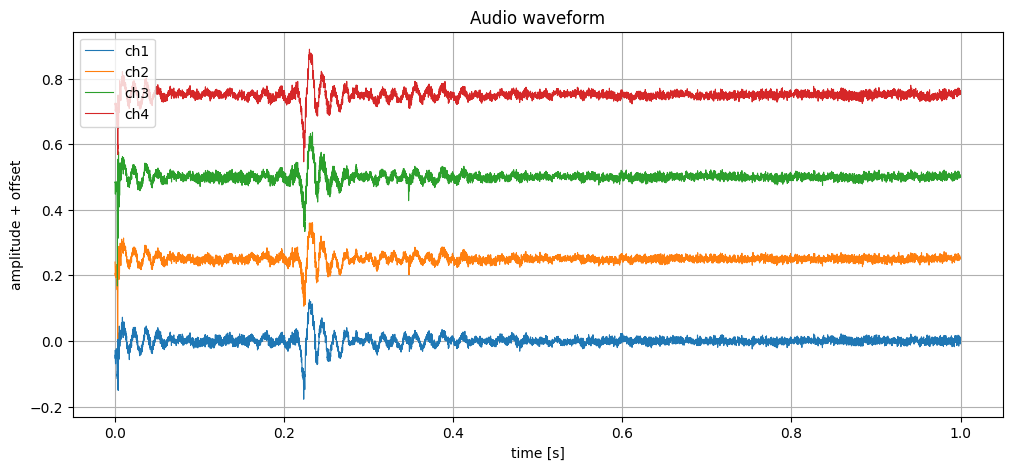

In [38]:
audio = sample["audio_wave"].numpy()
sample_rate = sample["sample_rate"]
time_axis = np.arange(audio.shape[1]) / sample_rate

plt.figure(figsize=(12, 5))
for ch in range(audio.shape[0]):
    plt.plot(time_axis, audio[ch] + ch * 0.25, label=f"ch{AUDIO_CHANNELS[ch]}", linewidth=0.8)
plt.xlabel("time [s]")
plt.ylabel("amplitude + offset")
plt.title("Audio waveform")
plt.legend()
plt.show()

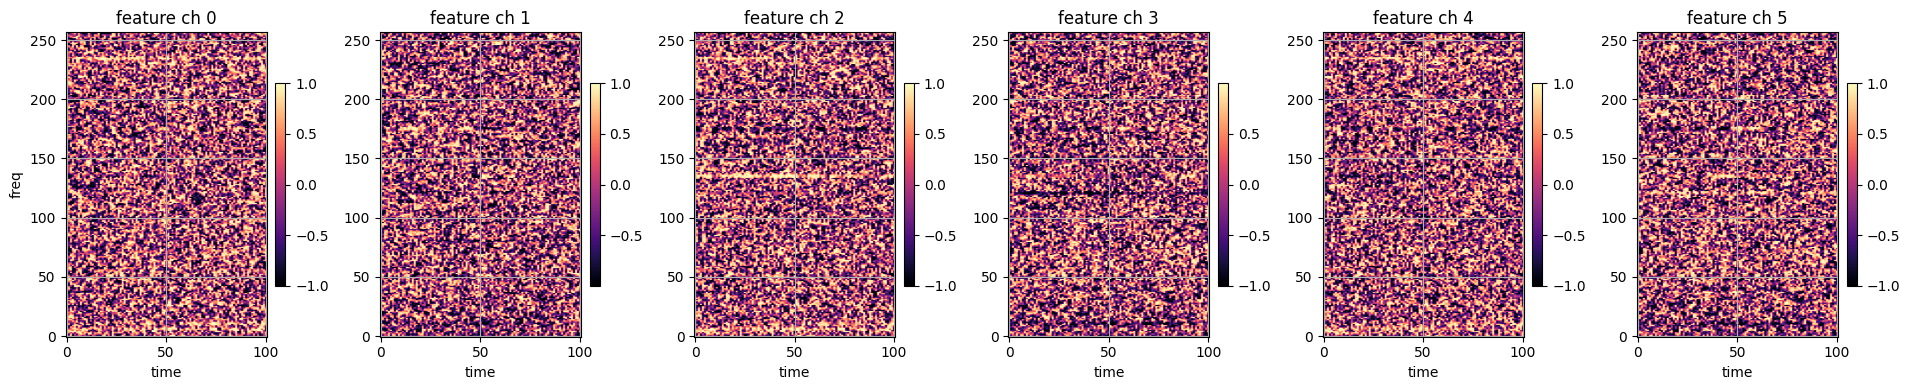

spectrogram shape: (12, 257, 101)
IPD pairs: ((0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3))


In [7]:
spec = sample["spectrogram"].numpy()  # (C, F, T)
num_show = min(spec.shape[0], 6)

fig, axes = plt.subplots(1, num_show, figsize=(3.2 * num_show, 4), squeeze=False)
for i in range(num_show):
    ax = axes[0, i]
    im = ax.imshow(spec[i], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"feature ch {i}")
    ax.set_xlabel("time")
    if i == 0:
        ax.set_ylabel("freq")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("spectrogram shape:", spec.shape)
print("IPD pairs:", IPD_PAIRS)

## 4. 可视化图像模态

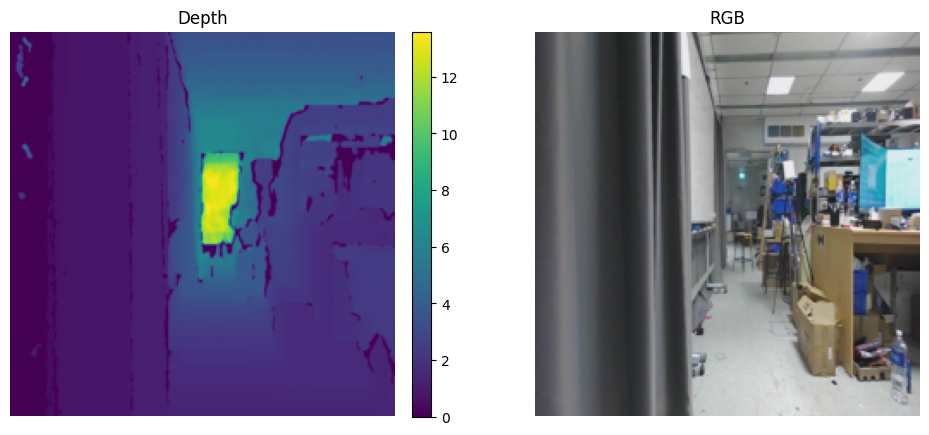

In [8]:
depth = sample["depth"].squeeze(0).numpy()
rgb = sample["rgb"].permute(1, 2, 0).numpy()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(depth, cmap="viridis")
plt.colorbar(fraction=0.046, pad=0.04)
depth_title = "Depth" if dataset.file_list[SAMPLE_INDEX]["depth"] is not None else "Depth placeholder: missing file"
plt.title(depth_title)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(rgb, 0.0, 1.0))
plt.title("RGB")
plt.axis("off")
plt.show()

## 5. 可视化 DOA 和距离标签

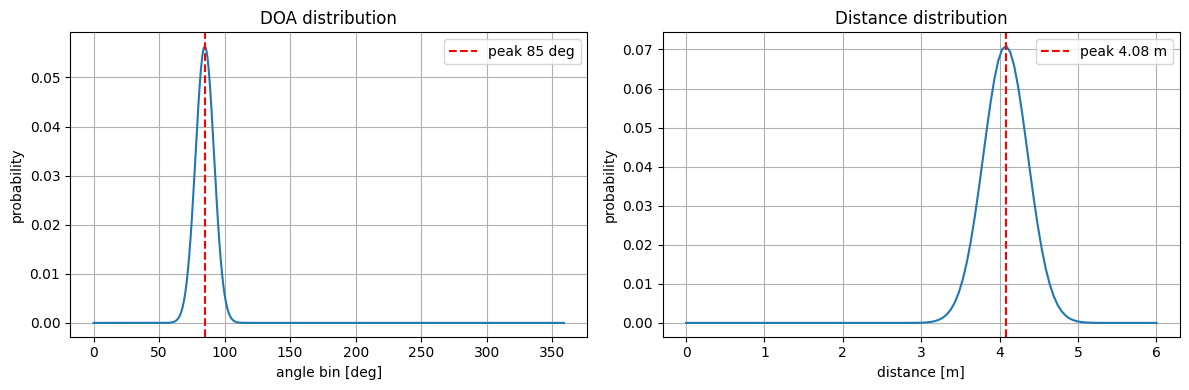

In [9]:
doa_map = sample["doa_map"].numpy()
dist_map = sample["distant_map"].numpy()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(doa_map)
plt.axvline(int(doa_map.argmax()), color="r", linestyle="--", label=f"peak {int(doa_map.argmax())} deg")
plt.xlabel("angle bin [deg]")
plt.ylabel("probability")
plt.title("DOA distribution")
plt.legend()

plt.subplot(1, 2, 2)
r_axis = np.linspace(0.0, 6.0, len(dist_map))
plt.plot(r_axis, dist_map)
peak_idx = int(dist_map.argmax())
plt.axvline(r_axis[peak_idx], color="r", linestyle="--", label=f"peak {r_axis[peak_idx]:.2f} m")
plt.xlabel("distance [m]")
plt.ylabel("probability")
plt.title("Distance distribution")
plt.legend()
plt.tight_layout()
plt.show()

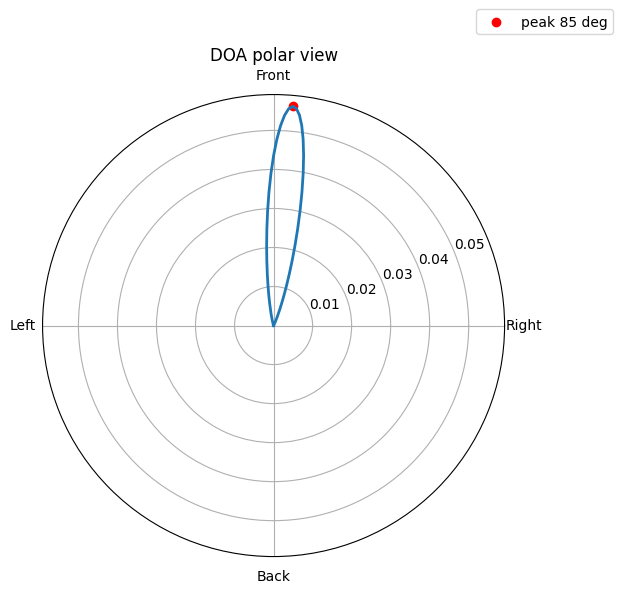

In [10]:
theta = np.linspace(0.0, 2 * np.pi, len(doa_map), endpoint=False)
peak_idx = int(doa_map.argmax())

plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.plot(theta, doa_map, linewidth=2)
ax.scatter([theta[peak_idx]], [doa_map[peak_idx]], c="red", label=f"peak {peak_idx} deg")
ax.set_thetagrids([0, 90, 180, 270], labels=["Right", "Front", "Left", "Back"])
ax.set_title("DOA polar view")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.2))
plt.show()

## 6. 检查 DataLoader batch

In [11]:
loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=0)
batch = next(iter(loader))

for key in ["audio_wave", "spectrogram", "depth", "rgb", "doa_map", "distant_map", "distance", "doa_deg"]:
    value = batch[key]
    print(f"{key:12s}: shape={tuple(value.shape)}, dtype={value.dtype}")

print("paths:")
for path in batch["path"]:
    print(" ", path)

audio_wave  : shape=(4, 4, 16000), dtype=torch.float32
spectrogram : shape=(4, 12, 257, 101), dtype=torch.float32
depth       : shape=(4, 1, 224, 224), dtype=torch.float32
rgb         : shape=(4, 3, 224, 224), dtype=torch.float32
doa_map     : shape=(4, 360), dtype=torch.float32
distant_map : shape=(4, 120), dtype=torch.float32
distance    : shape=(4, 2), dtype=torch.float32
doa_deg     : shape=(4,), dtype=torch.float32
paths:
  /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock4/audio/000260.wav
  /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock4/audio/000210.wav
  /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock3/audio/000082.wav
  /home/kemove/yyz/audio-nav/ws_col/synced_dataset/clock5/audio/000074.wav


## 7. 全数据集 DOA / 距离统计

这一节会遍历所有样本，统计 DOA 和距离标签的整体分布、按子数据集的分布，以及 DOA 与距离之间的联合分布。

In [12]:
from collections import Counter, defaultdict

DOA_FIELD_INDEX = {
    "robot_x": 0,
    "robot_y": 1,
    "source_odom_x": 2,
    "source_odom_y": 3,
    "target_x": 4,
    "target_y": 5,
    "target_vector_world_x": 6,
    "target_vector_world_y": 7,
    "heading_world_x": 8,
    "heading_world_y": 9,
    "distance_xy": 10,
    "distance_3d": 11,
    "robot_heading_world_deg": 12,
    "target_azimuth_world_deg": 13,
    "heading_target_yaw_signed_deg": 14,
    "heading_target_yaw_abs_deg": 15,
}

yaw_deg = []
yaw_abs_deg = []
robot_heading_deg = []
target_azimuth_deg = []
distance_xy = []
distance_3d = []
dataset_names = []
sample_ids = []

for item in dataset.file_list:
    doa = np.load(item["doa"]).astype(np.float32)
    dist = np.load(item["distance"]).astype(np.float32)
    yaw_deg.append(float(doa[DOA_FIELD_INDEX["heading_target_yaw_signed_deg"]]))
    yaw_abs_deg.append(float(doa[DOA_FIELD_INDEX["heading_target_yaw_abs_deg"]]))
    robot_heading_deg.append(float(doa[DOA_FIELD_INDEX["robot_heading_world_deg"]]))
    target_azimuth_deg.append(float(doa[DOA_FIELD_INDEX["target_azimuth_world_deg"]]))
    distance_xy.append(float(dist[0]))
    distance_3d.append(float(dist[1] if len(dist) > 1 else dist[0]))
    dataset_names.append(Path(item["dataset_dir"]).name)
    sample_ids.append(item["sample_id"])

yaw_deg = np.asarray(yaw_deg)
yaw_abs_deg = np.asarray(yaw_abs_deg)
robot_heading_deg = np.asarray(robot_heading_deg)
target_azimuth_deg = np.asarray(target_azimuth_deg)
distance_xy = np.asarray(distance_xy)
distance_3d = np.asarray(distance_3d)
dataset_names = np.asarray(dataset_names)
sample_ids = np.asarray(sample_ids)

def describe(name, values):
    values = np.asarray(values, dtype=np.float32)
    percentiles = np.percentile(values, [0, 1, 5, 25, 50, 75, 95, 99, 100])
    print(f"{name}")
    print(f"  count: {len(values)}")
    print(f"  mean/std: {values.mean():.4f} / {values.std():.4f}")
    print(f"  min/max: {values.min():.4f} / {values.max():.4f}")
    print("  percentiles [0,1,5,25,50,75,95,99,100]:")
    print(" ", np.array2string(percentiles, precision=4, separator=", "))

print("total samples:", len(dataset))
print("dataset counts:")
for name, count in sorted(Counter(dataset_names).items()):
    print(f"  {name}: {count}")

print("\nsummary statistics:")
describe("signed DOA yaw [deg]", yaw_deg)
describe("absolute DOA yaw [deg]", yaw_abs_deg)
describe("distance xy [m]", distance_xy)
describe("distance 3d [m]", distance_3d)
describe("robot heading world [deg]", robot_heading_deg)
describe("target azimuth world [deg]", target_azimuth_deg)

total samples: 1022
dataset counts:
  clock2: 125
  clock3: 310
  clock4: 314
  clock5: 273

summary statistics:
signed DOA yaw [deg]
  count: 1022
  mean/std: -19.4767 / 66.0605
  min/max: -177.8546 / 179.3598
  percentiles [0,1,5,25,50,75,95,99,100]:
  [-177.8546, -176.5299, -119.8095,  -49.377 ,  -15.645 ,    2.6215,
  100.1245,  175.8144,  179.3598]
absolute DOA yaw [deg]
  count: 1022
  mean/std: 50.0095 / 47.3538
  min/max: 0.0000 / 179.3598
  percentiles [0,1,5,25,50,75,95,99,100]:
  [0.0000e+00, 4.5742e-02, 9.4065e-01, 1.2513e+01, 3.6497e+01, 7.0858e+01,
 1.6134e+02, 1.7677e+02, 1.7936e+02]
distance xy [m]
  count: 1022
  mean/std: 2.3738 / 1.4911
  min/max: 0.0000 / 5.5284
  percentiles [0,1,5,25,50,75,95,99,100]:
  [0.0000e+00, 2.0650e-03, 7.2337e-03, 1.1833e+00, 2.1947e+00, 3.6508e+00,
 4.8240e+00, 5.1782e+00, 5.5284e+00]
distance 3d [m]
  count: 1022
  mean/std: 2.3739 / 1.4911
  min/max: 0.0000 / 5.5286
  percentiles [0,1,5,25,50,75,95,99,100]:
  [0.0000e+00, 2.6173e-03, 7

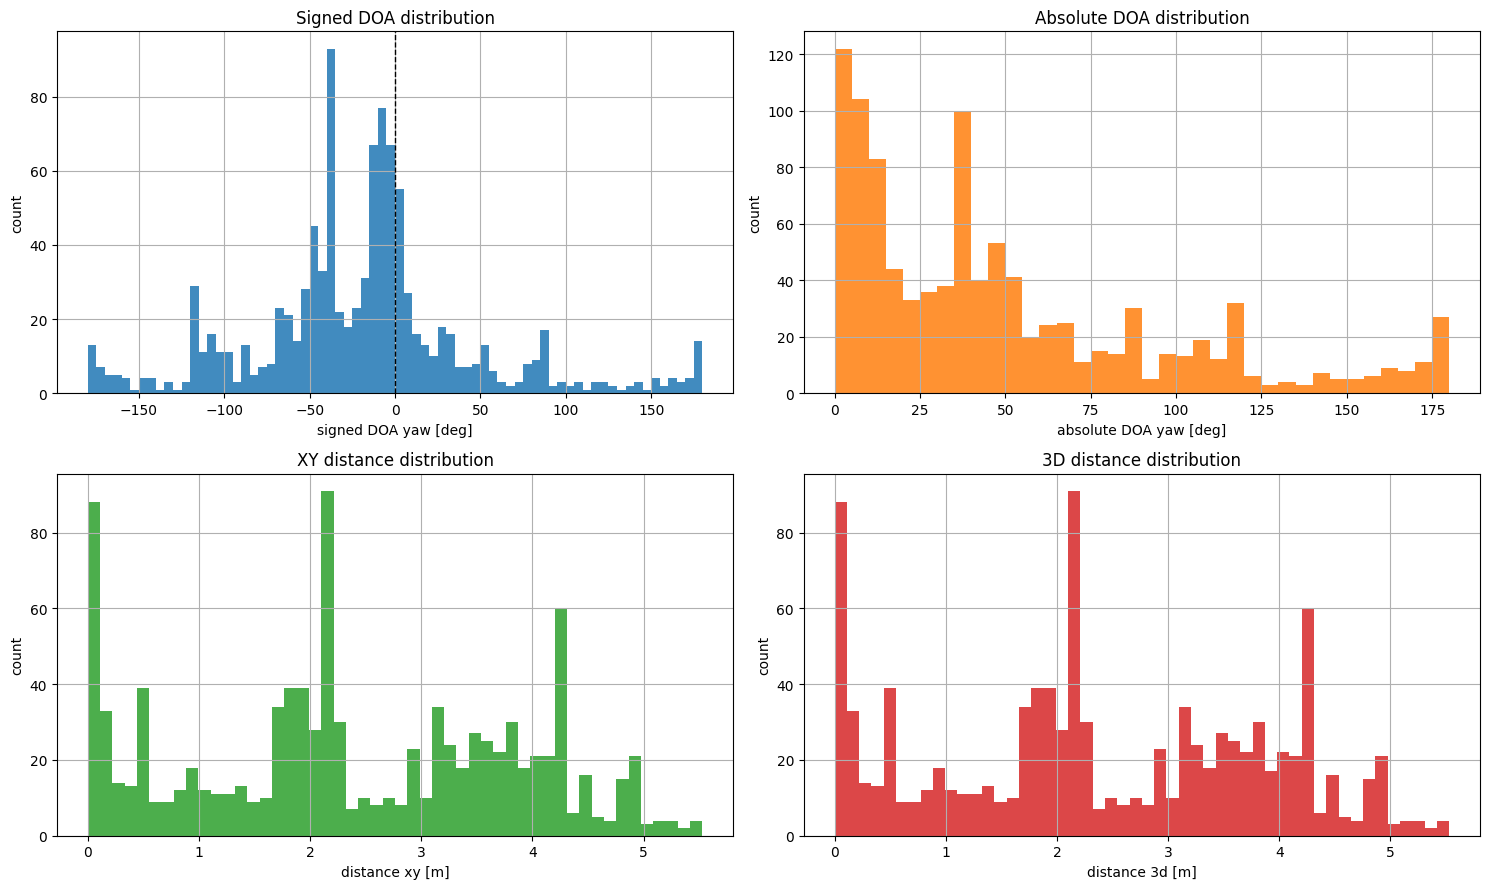

In [13]:
plt.figure(figsize=(15, 9))

plt.subplot(2, 2, 1)
plt.hist(yaw_deg, bins=72, range=(-180, 180), color="tab:blue", alpha=0.85)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("signed DOA yaw [deg]")
plt.ylabel("count")
plt.title("Signed DOA distribution")

plt.subplot(2, 2, 2)
plt.hist(yaw_abs_deg, bins=36, range=(0, 180), color="tab:orange", alpha=0.85)
plt.xlabel("absolute DOA yaw [deg]")
plt.ylabel("count")
plt.title("Absolute DOA distribution")

plt.subplot(2, 2, 3)
plt.hist(distance_xy, bins=50, color="tab:green", alpha=0.85)
plt.xlabel("distance xy [m]")
plt.ylabel("count")
plt.title("XY distance distribution")

plt.subplot(2, 2, 4)
plt.hist(distance_3d, bins=50, color="tab:red", alpha=0.85)
plt.xlabel("distance 3d [m]")
plt.ylabel("count")
plt.title("3D distance distribution")
plt.tight_layout()
plt.show()

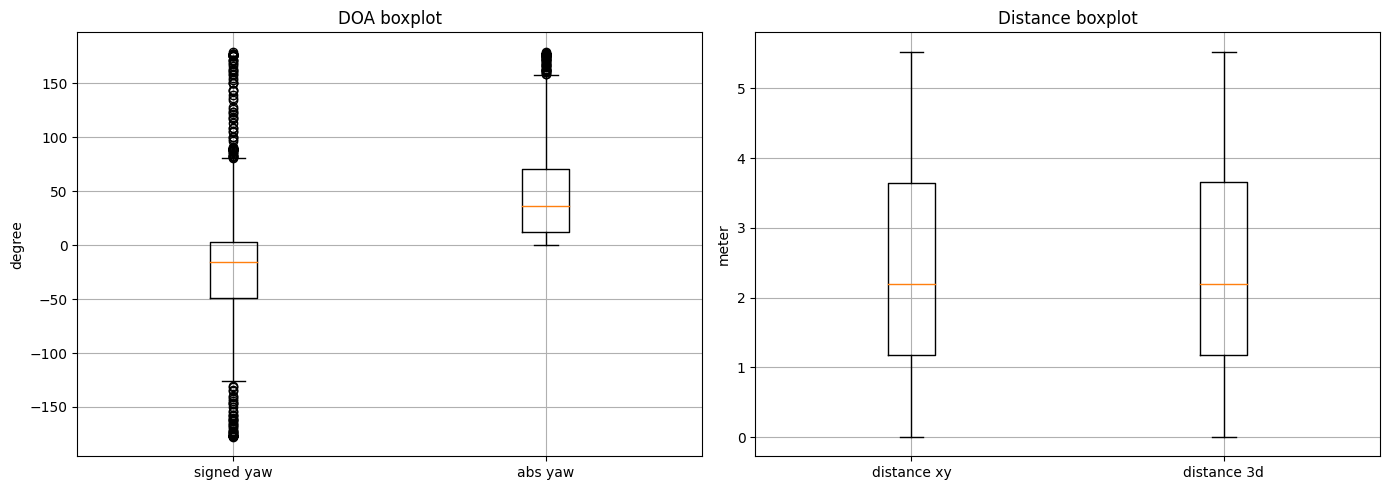

In [14]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.boxplot([yaw_deg, yaw_abs_deg], labels=["signed yaw", "abs yaw"], showfliers=True)
plt.ylabel("degree")
plt.title("DOA boxplot")

plt.subplot(1, 2, 2)
plt.boxplot([distance_xy, distance_3d], labels=["distance xy", "distance 3d"], showfliers=True)
plt.ylabel("meter")
plt.title("Distance boxplot")

plt.tight_layout()
plt.show()

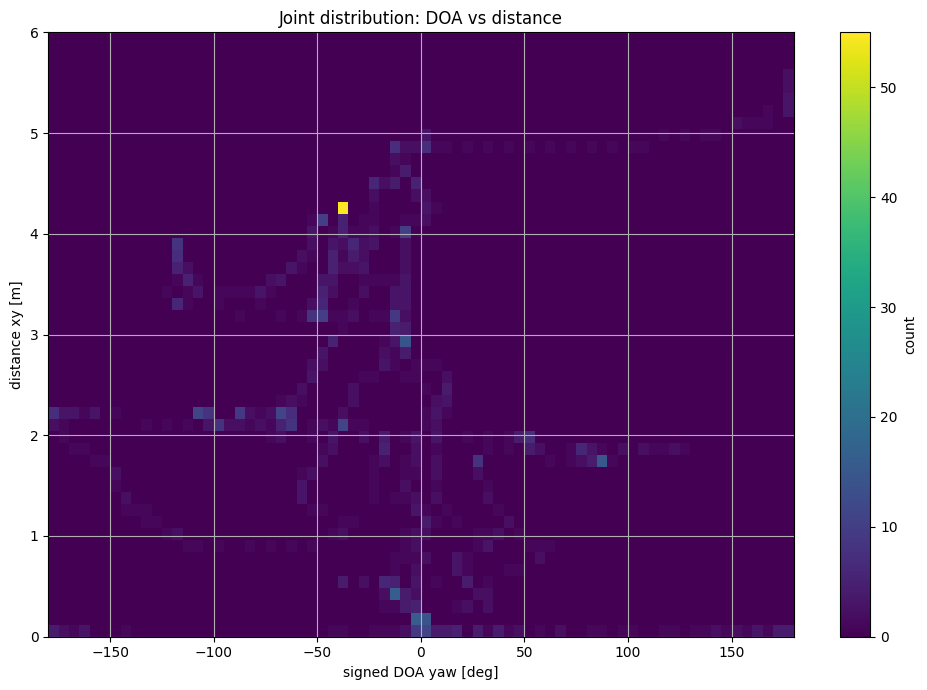

In [15]:
plt.figure(figsize=(10, 7))
hist = plt.hist2d(yaw_deg, distance_xy, bins=[72, 50], range=[[-180, 180], [0, max(6.0, float(distance_xy.max()))]], cmap="viridis")
plt.colorbar(hist[3], label="count")
plt.xlabel("signed DOA yaw [deg]")
plt.ylabel("distance xy [m]")
plt.title("Joint distribution: DOA vs distance")
plt.tight_layout()
plt.show()

In [16]:
angle_edges = np.linspace(-180, 180, 13)
distance_edges = np.array([0, 0.5, 1, 1.5, 2, 3, 4, 6, 10], dtype=np.float32)

angle_counts, _ = np.histogram(yaw_deg, bins=angle_edges)
distance_counts, _ = np.histogram(distance_xy, bins=distance_edges)

print("DOA bins, 30 deg per bin:")
for left, right, count in zip(angle_edges[:-1], angle_edges[1:], angle_counts):
    print(f"  [{left:7.1f}, {right:7.1f}) deg: {count:5d} ({count / len(yaw_deg) * 100:5.2f}%)")

print("\nDistance xy bins:")
for left, right, count in zip(distance_edges[:-1], distance_edges[1:], distance_counts):
    print(f"  [{left:4.1f}, {right:4.1f}) m: {count:5d} ({count / len(distance_xy) * 100:5.2f}%)")

DOA bins, 30 deg per bin:
  [ -180.0,  -150.0) deg:    35 ( 3.42%)
  [ -150.0,  -120.0) deg:    16 ( 1.57%)
  [ -120.0,   -90.0) deg:    81 ( 7.93%)
  [  -90.0,   -60.0) deg:    77 ( 7.53%)
  [  -60.0,   -30.0) deg:   235 (22.99%)
  [  -30.0,     0.0) deg:   283 (27.69%)
  [    0.0,    30.0) deg:   139 (13.60%)
  [   30.0,    60.0) deg:    57 ( 5.58%)
  [   60.0,    90.0) deg:    42 ( 4.11%)
  [   90.0,   120.0) deg:    14 ( 1.37%)
  [  120.0,   150.0) deg:    12 ( 1.17%)
  [  150.0,   180.0) deg:    31 ( 3.03%)

Distance xy bins:
  [ 0.0,  0.5) m:   172 (16.83%)
  [ 0.5,  1.0) m:    63 ( 6.16%)
  [ 1.0,  1.5) m:    52 ( 5.09%)
  [ 1.5,  2.0) m:   127 (12.43%)
  [ 2.0,  3.0) m:   216 (21.14%)
  [ 3.0,  4.0) m:   207 (20.25%)
  [ 4.0,  6.0) m:   185 (18.10%)
  [ 6.0, 10.0) m:     0 ( 0.00%)


In [17]:
per_dataset = defaultdict(list)
for name, yaw, dist_xy, dist_3d in zip(dataset_names, yaw_deg, distance_xy, distance_3d):
    per_dataset[name].append((yaw, dist_xy, dist_3d))

print("per-dataset summary:")
print(f"{'dataset':20s} {'count':>7s} {'yaw_mean':>10s} {'yaw_std':>10s} {'dist_mean':>10s} {'dist_std':>10s}")
for name in sorted(per_dataset):
    arr = np.asarray(per_dataset[name], dtype=np.float32)
    print(f"{name:20s} {len(arr):7d} {arr[:,0].mean():10.3f} {arr[:,0].std():10.3f} {arr[:,1].mean():10.3f} {arr[:,1].std():10.3f}")

per-dataset summary:
dataset                count   yaw_mean    yaw_std  dist_mean   dist_std
clock2                   125      1.448     38.625      1.994      1.344
clock3                   310    -10.544     84.770      1.781      1.235
clock4                   314    -38.688     41.905      2.851      1.490
clock5                   273    -17.105     68.943      2.672      1.548


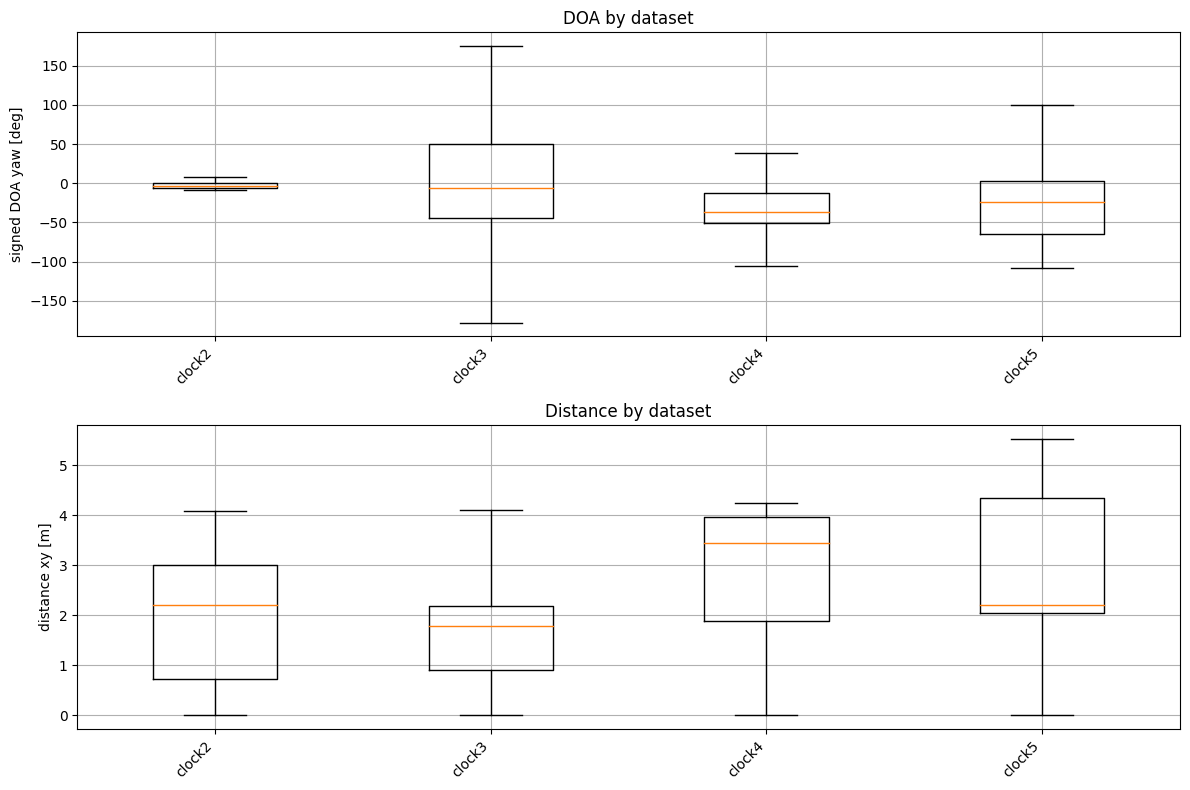

In [18]:
names = sorted(per_dataset)
if len(names) > 1:
    yaw_by_dataset = [np.asarray(per_dataset[name], dtype=np.float32)[:, 0] for name in names]
    dist_by_dataset = [np.asarray(per_dataset[name], dtype=np.float32)[:, 1] for name in names]

    plt.figure(figsize=(max(12, len(names) * 0.8), 8))
    plt.subplot(2, 1, 1)
    plt.boxplot(yaw_by_dataset, labels=names, showfliers=False)
    plt.ylabel("signed DOA yaw [deg]")
    plt.title("DOA by dataset")
    plt.xticks(rotation=45, ha="right")

    plt.subplot(2, 1, 2)
    plt.boxplot(dist_by_dataset, labels=names, showfliers=False)
    plt.ylabel("distance xy [m]")
    plt.title("Distance by dataset")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Only one dataset folder found; skip per-dataset boxplot.")